## mpg dataset example

In [3]:
# Import necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression 

from sklearn.metrics import r2_score, root_mean_squared_error 

# Set the plotting style
sns.set_theme(style="darkgrid", palette="husl")
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# load the dataset
df = sns.load_dataset("mpg")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [7]:
# Display the data types and missing values information
print(df.shape)
df.info()

(398, 9)
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [6]:
# Display summary statistics for number columns
df.describe(include= 'number')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [8]:
# Display summary statistics for categorical data
df.describe(include= 'object')

C:\Users\TALAL ALOTHMAN\AppData\Local\Temp\ipykernel_4176\939729090.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include= 'object')


,origin,name
count,398,398
unique,3,305
top,usa,ford pinto
freq,249,6


In [10]:
# Check for missing values
df.isnull().mean().sort_values(ascending=False)*100

horsepower      1.507538
mpg             0.000000
cylinders       0.000000
displacement    0.000000
weight          0.000000
acceleration    0.000000
model_year      0.000000
origin          0.000000
name            0.000000
dtype: float64

In [11]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [14]:
# Identify potential outliers for numerical columns
outliers_sum = {}
outliers_mean = {}

for col in df.select_dtypes(include=[np.number]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
        
    outliers_sum[col] = ( (df[col] < lower) | (df[col] > upper)).sum()
    outliers_mean[col] = ( (df[col] < lower) | (df[col] > upper)).mean()
        
print(outliers_sum)
print(outliers_mean)

{'mpg': np.int64(1), 'cylinders': np.int64(0), 'displacement': np.int64(0), 'horsepower': np.int64(10), 'weight': np.int64(0), 'acceleration': np.int64(7), 'model_year': np.int64(0)}
{'mpg': np.float64(0.002512562814070352), 'cylinders': np.float64(0.0), 'displacement': np.float64(0.0), 'horsepower': np.float64(0.02512562814070352), 'weight': np.float64(0.0), 'acceleration': np.float64(0.017587939698492462), 'model_year': np.float64(0.0)}


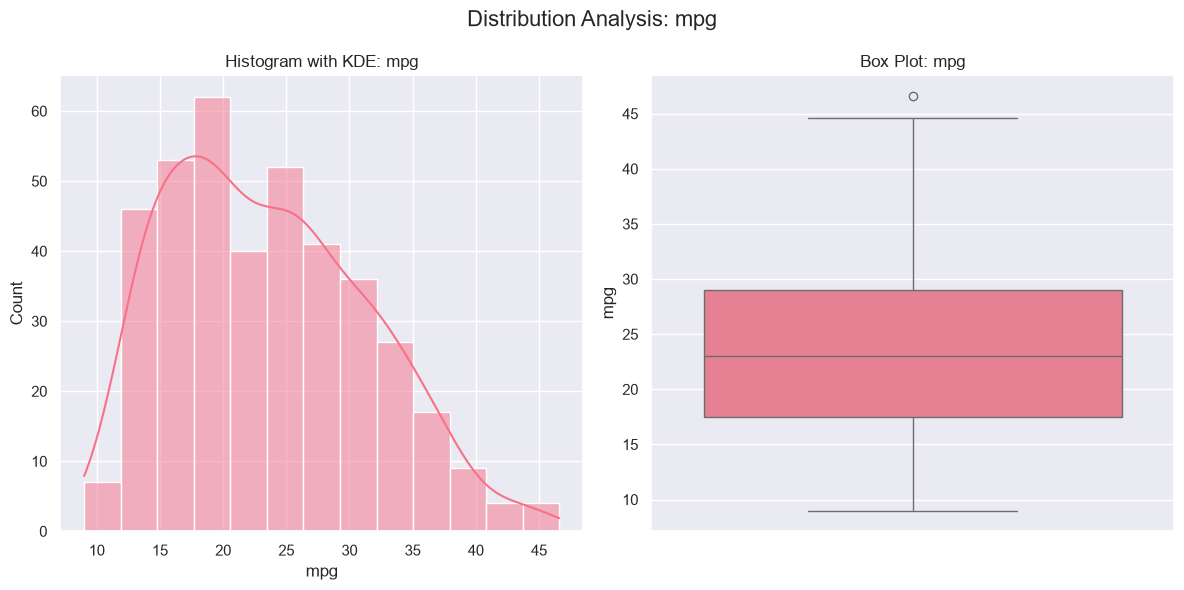

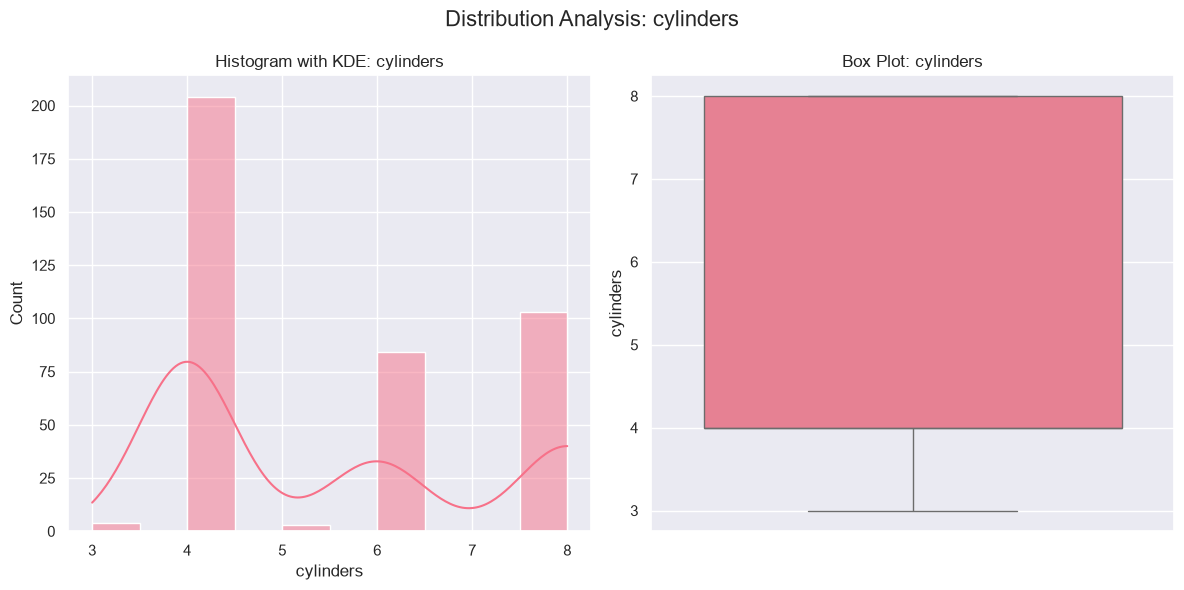

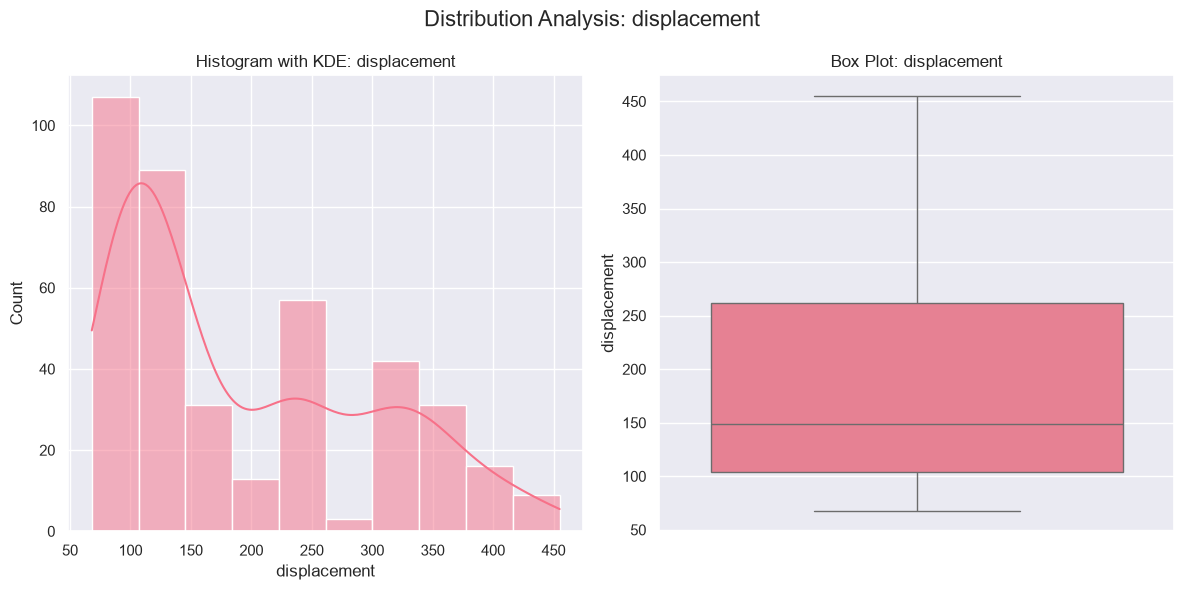

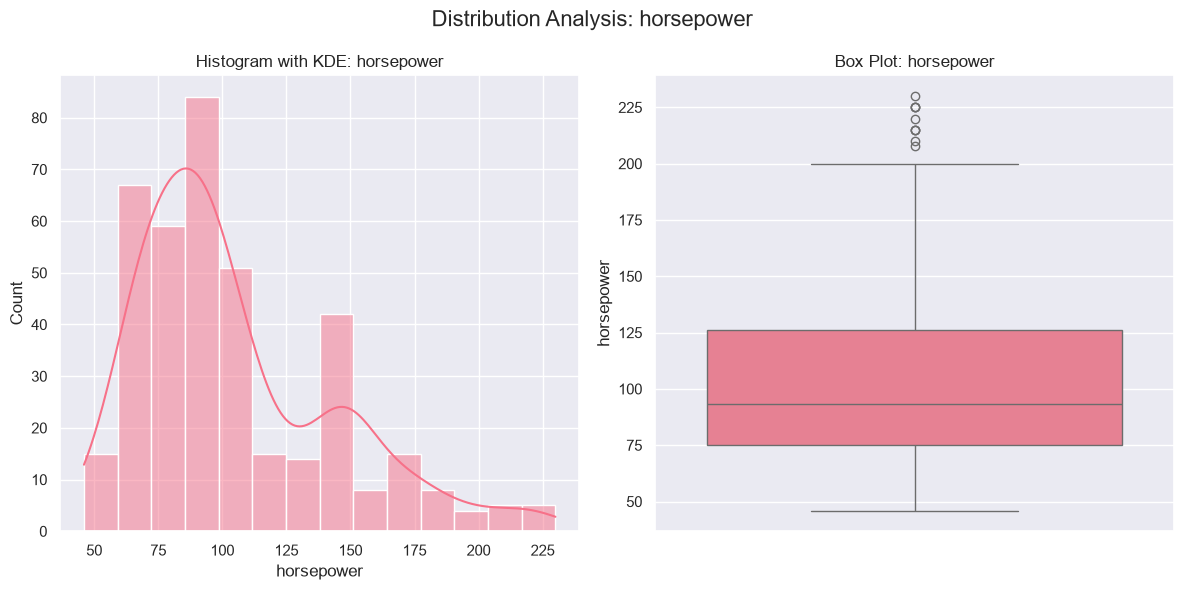

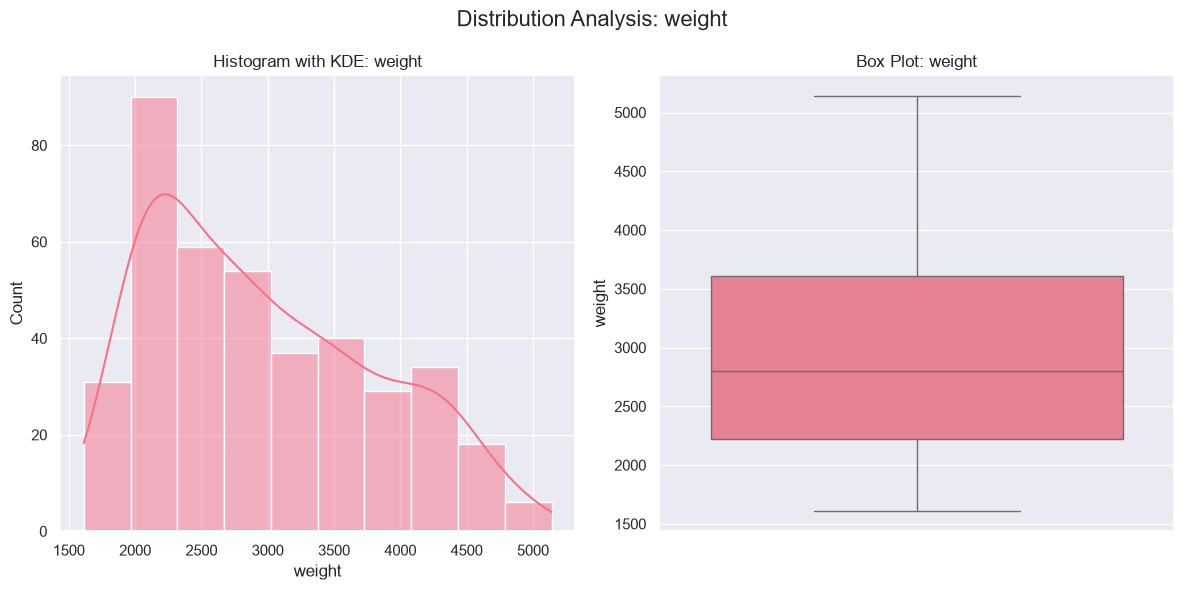

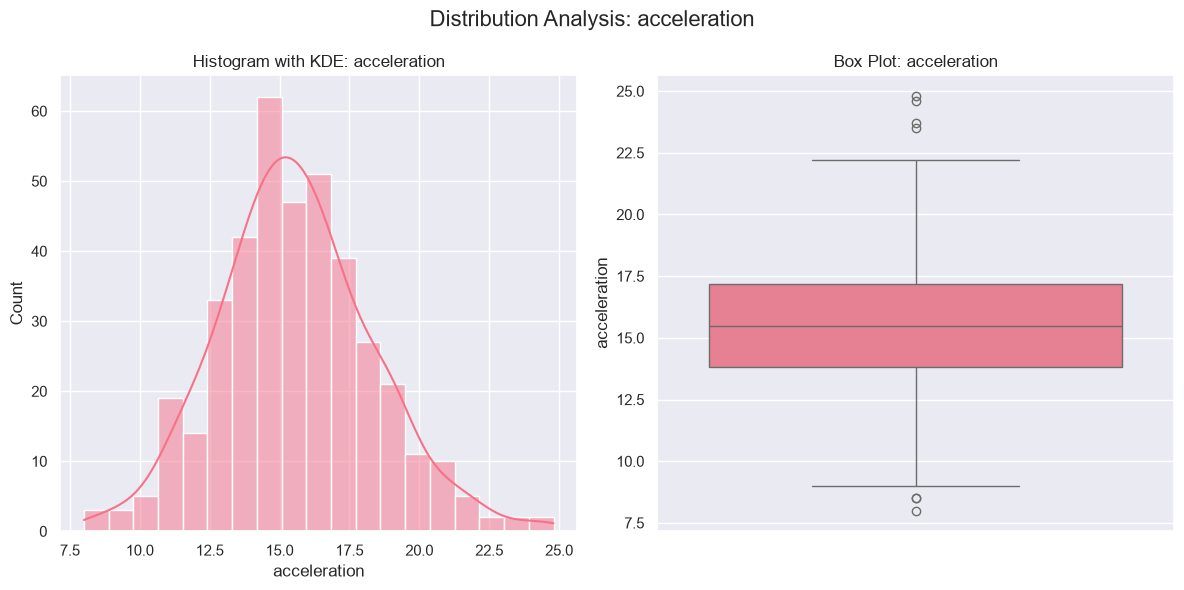

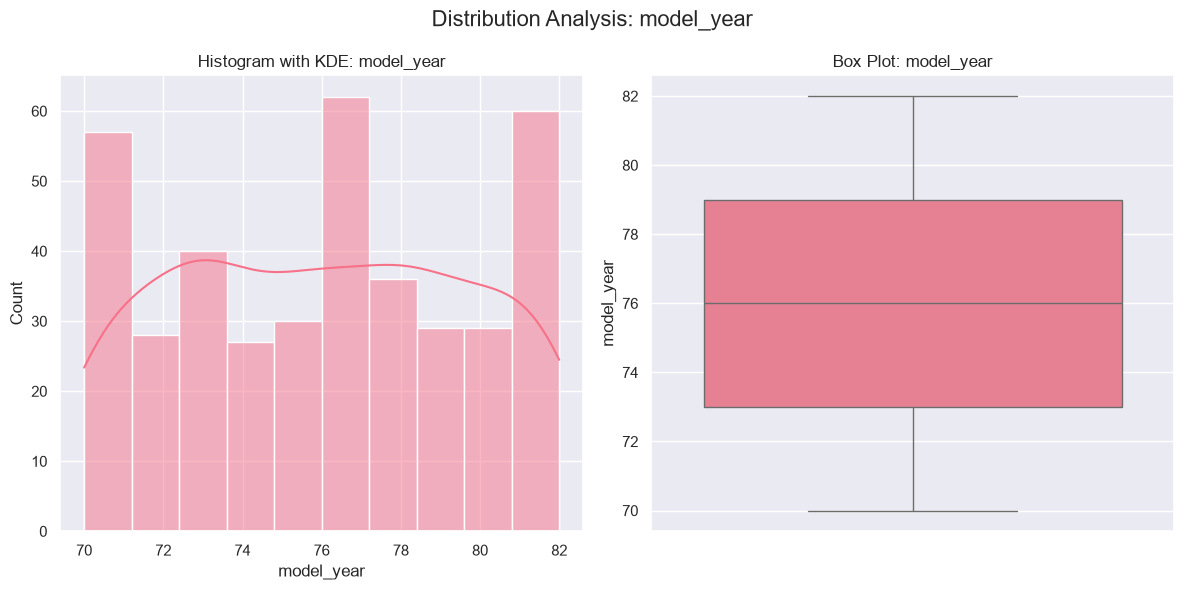

In [16]:
def visualize_distribution(df, column):
    """
    Create comprehensive visualization of a variable's distribution.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Create histogram with KDE
    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram with KDE: {column}')
    
    # Create box plot
    sns.boxplot(y=df[column], ax=axes[1])
    axes[1].set_title(f'Box Plot: {column}')
    
    plt.suptitle(f'Distribution Analysis: {column}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize some variables
for i in df.select_dtypes(include='number'):
    visualize_distribution(df, i)
